# Big Data: de lo básico a lo práctico
### Un recorrido práctico sobre cómo trabajar con datos que no caben en Excel

**Programa de hoy:**
1. Identificar el problema: por qué fallan las herramientas «normales»
2. La solución práctica: consultar gigabytes con DuckDB
3. Comparativa: pandas frente a DuckDB, cara a cara
4. Práctica 1: responder a preguntas reales con SQL
5. Más análisis y visualizaciones (opcional; se puede omitir si hay poco tiempo)
6. Puente: qué cambia cuando los datos no caben en una sola máquina (Spark)
7. Práctica 2: convertir una consulta en una recomendación práctica
8. Resumen: dónde encajan estas herramientas en un flujo de datos real

**Conjunto de datos:** registros de viajes de la Comisión de Taxis y Limusinas de Nueva York (públicos, reales, varios gigabytes) — https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

> Ejecuta cada celda en orden con **Mayús+Intro**. No es necesario instalar nada en tu propio portátil: todo se ejecuta en Colab.


## 0. Configuración

Ejecuta esto una sola vez. Este código instala los dos motores que compararemos con pandas sin modificaciones, **y
descarga de antemano todos los datos que necesitaremos**, de modo que el resto de la sesión no dependa
de que la conexión a Internet funcione correctamente.

El servidor de datos de Nueva York (CloudFront) rechazará ocasionalmente las solicitudes automáticas repetidas procedentes de
direcciones IP compartidas de aulas o Colab con un error `403`; esta celda realiza la descarga con reintentos y
guarda todo en el disco local *una sola vez*, de modo que nada de lo que venga después en el cuaderno vuelva a acceder a la
red.


In [ ]:
!pip install duckdb pyspark -q

import os
import time
import requests
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "/content/nyc_taxi_data"
os.makedirs(DATA_DIR, exist_ok=True)

# A normal browser-like header avoids some naive bot-blocking rules
HEADERS = {"User-Agent": "Mozilla/5.0 (classroom-demo)"}

def download(url, dest, max_retries=5):
    """Download url to dest with retries. Skips if already downloaded."""
    if os.path.exists(dest) and os.path.getsize(dest) > 0:
        return dest
    for attempt in range(max_retries):
        try:
            r = requests.get(url, headers=HEADERS, stream=True, timeout=60)
            r.raise_for_status()
            with open(dest, "wb") as f:
                for chunk in r.iter_content(chunk_size=1024 * 1024):
                    f.write(chunk)
            return dest
        except Exception as e:
            wait = 2 ** attempt
            print(f"  attempt {attempt + 1} failed ({e}) — retrying in {wait}s")
            time.sleep(wait)
    raise RuntimeError(f"Could not download {url} after {max_retries} attempts")

print("Ready. DuckDB version:", duckdb.__version__)


Ready. DuckDB version: 1.3.2


In [ ]:
# Download 6 months of trip data + the zone lookup table, once, to local disk.
# This is the ONLY cell in the whole notebook that talks to the internet.

months = [f"2024-{m:02d}" for m in range(1, 7)]
local_files = []

for m in months:
    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{m}.parquet"
    dest = f"{DATA_DIR}/yellow_tripdata_{m}.parquet"
    print(f"Downloading {m}...")
    download(url, dest)
    local_files.append(dest)

zone_path = f"{DATA_DIR}/taxi_zone_lookup.csv"
download("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv", zone_path)

file_list_sql = ", ".join(f"'{p}'" for p in local_files)
print("\nAll files ready locally:")
for f in local_files:
    print(" -", f, f"({os.path.getsize(f) / 1e6:.1f} MB)")



All files ready locally:
 - /content/nyc_taxi_data/yellow_tripdata_2024-01.parquet (50.0 MB)
 - /content/nyc_taxi_data/yellow_tripdata_2024-02.parquet (50.3 MB)
 - /content/nyc_taxi_data/yellow_tripdata_2024-03.parquet (60.1 MB)
 - /content/nyc_taxi_data/yellow_tripdata_2024-04.parquet (59.1 MB)
 - /content/nyc_taxi_data/yellow_tripdata_2024-05.parquet (62.6 MB)
 - /content/nyc_taxi_data/yellow_tripdata_2024-06.parquet (59.9 MB)


## 1. Sintiendo el dolor

Ya tenemos **un mes** de viajes en taxi amarillo de Nueva York almacenados en disco (unos cuantos millones de filas,
~50 MB en formato Parquet). Veamos cuánto tarda Pandas sin más en cargar y resumir esos datos —
sin conexión a red, por lo que se trata exclusivamente del rendimiento propio de Pandas.


In [ ]:
start = time.time()
df = pd.read_parquet(local_files[0])
load_time = time.time() - start

print(f"Rows loaded: {len(df):,}")
print(f"Load time: {load_time:.2f} seconds")
df.head()


Rows loaded: 2,964,624
Load time: 1.01 seconds


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


In [ ]:
# Now do something simple: average fare by hour of day
start = time.time()
df["hour"] = pd.to_datetime(df["tpep_pickup_datetime"]).dt.hour
result = df.groupby("hour")["fare_amount"].mean()
query_time = time.time() - start

print(f"Groupby time: {query_time:.2f} seconds")
result


Groupby time: 0.32 seconds


,fare_amount
hour,
0,19.202658
1,17.527296
2,16.482882
3,18.150135
4,22.518645
5,26.619918
6,21.650399
7,18.539180
8,17.654683


Eso es *un mes*. El conjunto de datos completo (desde 2009 hasta la actualidad) equivale a muchos años de esto, repartidos en
cientos de archivos y decenas de gigabytes. Cargarlo todo en pandas agotaría la RAM
de esta máquina de Colab; ese es el momento en el que el «big data» deja de ser una palabra de moda y empieza a ser
un verdadero problema de ingeniería.

**Debate:** ¿qué es lo primero que fallaría: la descarga, la memoria o el cálculo?


## 2. La solución práctica: DuckDB

DuckDB es un motor SQL que se ejecuta *en el propio proceso* (sin servidor ni clúster) y está diseñado para procesar
gigabytes en un solo portátil. El truco: no necesita cargarlo todo primero en la memoria, sino que lo procesa en tiempo real y aplica los filtros directamente en el propio archivo.

Mira cómo consulta **los seis meses de una sola vez** (que ya están en el disco desde la sección 0) en
aproximadamente el mismo tiempo que tardó pandas en cargar *uno*.


In [ ]:
con = duckdb.connect()

start = time.time()
result = con.sql(f"""
    SELECT
        EXTRACT(hour FROM tpep_pickup_datetime) AS hour,
        COUNT(*) AS trips,
        AVG(fare_amount) AS avg_fare
    FROM read_parquet([{file_list_sql}])
    GROUP BY hour
    ORDER BY hour
""").df()
query_time = time.time() - start

print(f"Query time across all 6 months: {query_time:.2f} seconds")
result


Query time across all 6 months: 0.82 seconds


,hour,trips,avg_fare
0,0,587348,19.185572
1,1,382094,17.241757
2,2,249265,16.167960
3,3,165772,17.157034
4,4,120837,22.106574
5,5,128239,25.889151
6,6,285526,22.012887
7,7,565902,19.043894
8,8,781643,18.298297
9,9,852945,18.178901


La misma consulta, seis veces más datos y (por lo general) más rápido que pandas al cargar un solo mes. Por eso DuckDB es la puerta de entrada práctica al «big data»: la mayoría de los conjuntos de datos reales de
las aulas y las pequeñas empresas nunca necesitan más que esto.


## 3. Prueba de rendimiento: pandas frente a DuckDB, comparación directa

Hagamos una comparación rigurosa en lugar de anecdótica: ejecutemos las **mismas cuatro operaciones**
sobre los **mismos datos** con cada motor y cronometremos cada paso.

Para ello, utilizaremos 3 meses (no los 6) para que el consumo de memoria de pandas no suponga un problema en una instancia estándar de Colab;
aumenta el valor de `N_BENCHMARK_MONTHS` si dispones de más RAM.


In [ ]:
N_BENCHMARK_MONTHS = 3  # increase to 6 if you have a high-RAM runtime
bench_files = local_files[:N_BENCHMARK_MONTHS]
bench_file_list_sql = ", ".join(f"'{p}'" for p in bench_files)

timings = {"pandas": {}, "duckdb": {}}

# ---------- pandas ----------
start = time.time()
pandas_df = pd.concat([pd.read_parquet(f) for f in bench_files], ignore_index=True)
timings["pandas"]["load"] = time.time() - start

start = time.time()
_ = pandas_df[pandas_df["fare_amount"] > 50]
timings["pandas"]["filter"] = time.time() - start

start = time.time()
pandas_df["hour"] = pd.to_datetime(pandas_df["tpep_pickup_datetime"]).dt.hour
_ = pandas_df.groupby("hour")["fare_amount"].mean()
timings["pandas"]["groupby"] = time.time() - start

start = time.time()
zones_df = pd.read_csv(zone_path)
merged = pandas_df.merge(zones_df, left_on="PULocationID", right_on="LocationID")
_ = merged.groupby("Borough")["tip_amount"].mean()
timings["pandas"]["join+groupby"] = time.time() - start

# ---------- duckdb ----------
bcon = duckdb.connect()

start = time.time()
bcon.sql(f"CREATE OR REPLACE VIEW trips AS SELECT * FROM read_parquet([{bench_file_list_sql}])")
bcon.sql("SELECT COUNT(*) FROM trips").fetchall()  # force a full scan, for a fair comparison
timings["duckdb"]["load"] = time.time() - start

start = time.time()
bcon.sql("SELECT COUNT(*) FROM trips WHERE fare_amount > 50").fetchall()
timings["duckdb"]["filter"] = time.time() - start

start = time.time()
bcon.sql("""
    SELECT EXTRACT(hour FROM tpep_pickup_datetime) AS hour, AVG(fare_amount)
    FROM trips GROUP BY hour
""").df()
timings["duckdb"]["groupby"] = time.time() - start

start = time.time()
bcon.sql(f"""
    SELECT z.Borough, AVG(t.tip_amount)
    FROM trips t JOIN read_csv_auto('{zone_path}') z ON t.PULocationID = z.LocationID
    GROUP BY z.Borough
""").df()
timings["duckdb"]["join+groupby"] = time.time() - start

timing_df = pd.DataFrame(timings)
timing_df


,pandas,duckdb
load,2.996901,0.024437
filter,0.232218,0.100647
groupby,0.682227,0.538460
join+groupby,11.697141,0.912339


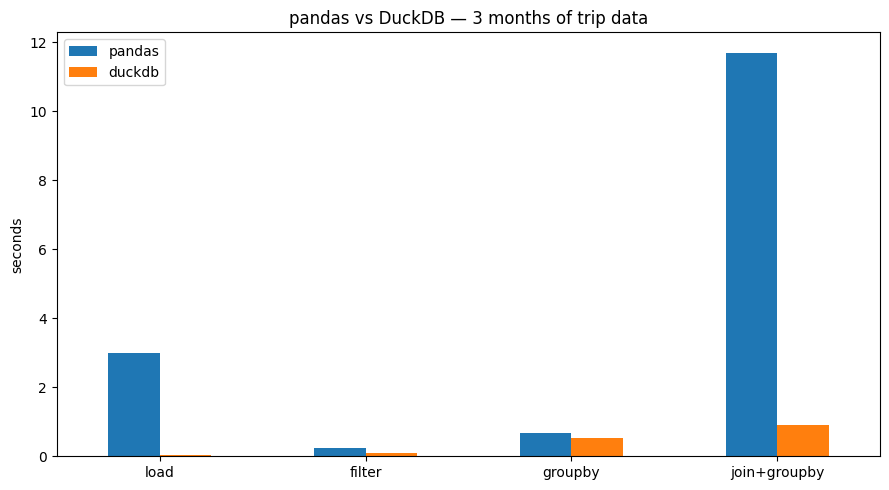

Total time (seconds):
pandas    15.608486
duckdb     1.575883
dtype: float64


In [ ]:
ax = timing_df.plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("seconds")
ax.set_title(f"pandas vs DuckDB — {N_BENCHMARK_MONTHS} months of trip data")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Total time (seconds):")
print(timing_df.sum())


**Una aclaración que merece la pena comentar en voz alta:** El paso de «carga» de DuckDB no crea una copia en memoria como hace pandas, sino que registra los archivos y realiza un único escaneo. Eso no es un truco, sino una diferencia arquitectónica real: DuckDB solo materializa las filas que necesita una consulta, mientras que pandas materializa todo por adelantado, lo necesites o no. La comparación más justa no es «qué motor carga más rápido», sino el **tiempo total
en los cuatro pasos**, es decir, el *tiempo de respuesta*, que es lo que muestra el resultado final anterior
.

**Debate:** ¿qué operación concreta muestra la mayor diferencia? ¿Coincide eso con lo que cabría esperar, teniendo en cuenta cómo funciona cada motor?


## 4. Práctica 1: responder a preguntas reales con SQL

Trabajar en parejas. Edita el código SQL de cada celda que aparece a continuación y vuelve a ejecutarlo. Utiliza el mismo patrón
`read_parquet([{file_list_sql}])` que antes, o simplemente reutiliza la conexión `con`.

También incorporaremos la tabla de consulta de zonas de taxis (que también ya se ha descargado) para que los números de «LocationID»
se conviertan en nombres de lugares reales.


In [ ]:
zones = con.sql(f"""
    SELECT * FROM read_csv_auto('{zone_path}')
""").df()
zones.head()


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


**Pregunta A — La hora de mayor actividad en las recogidas.** Ya se ha respondido más arriba; echa un vistazo a la tabla «result».
¿Qué hora tiene más viajes? ¿Coincide eso con lo que pensabas?

**Pregunta B — ¿Qué distrito recibe las mejores propinas?** Rellena la consulta que aparece a continuación.


In [ ]:
tips_by_borough = con.sql(f"""
    SELECT
        z.Borough,
        AVG(t.tip_amount / NULLIF(t.fare_amount, 0)) AS avg_tip_pct,
        COUNT(*) AS trips
    FROM read_parquet([{file_list_sql}]) t
    JOIN read_csv_auto('{zone_path}') z
        ON t.PULocationID = z.LocationID
    WHERE t.fare_amount > 0
    GROUP BY z.Borough
    ORDER BY avg_tip_pct DESC
""").df()

tips_by_borough


,Borough,avg_tip_pct,trips
0,N/A,9.751971,10635
1,EWR,0.375634,2465
2,Manhattan,0.203729,17840139
3,Unknown,0.203208,64853
4,Queens,0.174398,1781409
5,Bronx,0.161443,58206
6,Brooklyn,0.096845,249678
7,Staten Island,0.087686,628


**Pregunta C — Te toca.** Escribe una consulta que responda a una de estas preguntas (elige una o inventa la tuya propia):
- ¿Qué día de la semana tiene la distancia media de viaje más larga?
- ¿Qué fracción de viajes no incluye propina alguna?
- ¿Existe alguna relación entre el número de pasajeros y el porcentaje de propina?

Edita la celda que aparece a continuación.


In [ ]:
your_query = con.sql(f"""
    SELECT
        -- write your columns here
        COUNT(*) AS trips
    FROM read_parquet([{file_list_sql}])
    -- add WHERE / GROUP BY / ORDER BY as needed
""").df()

your_query


,trips
0,20332093


## 5. Más análisis y visualizaciones

*Opcional: si tienes poco tiempo, pasa a la sección 6 y vuelve a esto más tarde.*

Unas cuantas perspectivas más sobre los mismos datos. Fíjate en el patrón que se repite en todas las celdas siguientes: DuckDB se encarga de la agregación pesada sobre millones de filas, y solo el pequeño *resultado* —unas pocas docenas de filas como máximo— se convierte en un DataFrame de pandas para su representación gráfica. Esa es la forma general de pasar de los «macrodatos a un gráfico útil»: primero se agrega, luego se carga.


**Payment type breakdown**


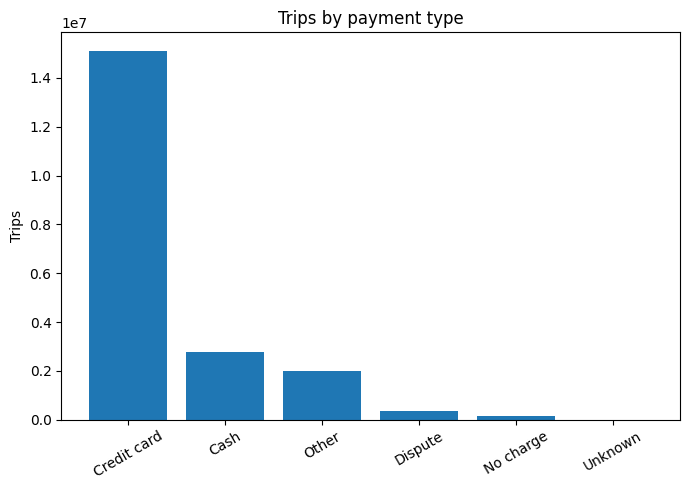

In [ ]:
payment_counts = con.sql(f"""
    SELECT payment_type, COUNT(*) AS trips
    FROM read_parquet([{file_list_sql}])
    GROUP BY payment_type
    ORDER BY trips DESC
""").df()

payment_labels = {1: "Credit card", 2: "Cash", 3: "No charge", 4: "Dispute", 5: "Unknown", 6: "Voided trip"}
payment_counts["label"] = payment_counts["payment_type"].map(payment_labels).fillna("Other")

plt.figure(figsize=(7, 5))
plt.bar(payment_counts["label"], payment_counts["trips"])
plt.ylabel("Trips")
plt.title("Trips by payment type")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Top 10 busiest pickup zones**


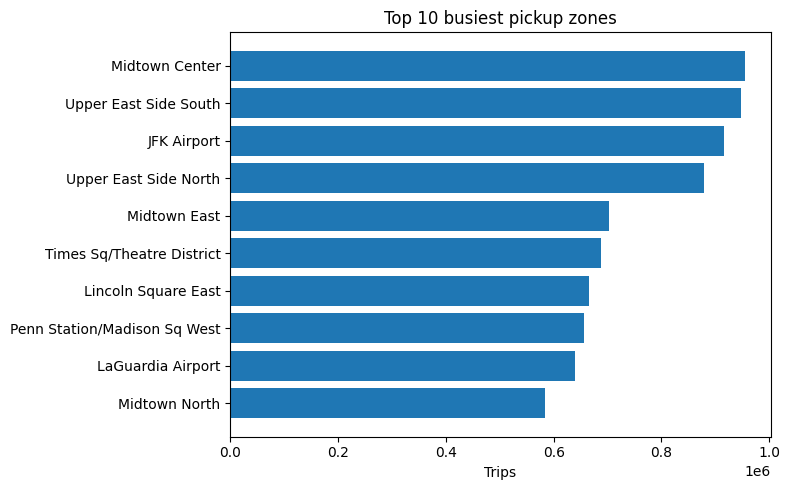

In [ ]:
top_zones = con.sql(f"""
    SELECT z.Zone, COUNT(*) AS trips
    FROM read_parquet([{file_list_sql}]) t
    JOIN read_csv_auto('{zone_path}') z ON t.PULocationID = z.LocationID
    GROUP BY z.Zone
    ORDER BY trips DESC
    LIMIT 10
""").df()

plt.figure(figsize=(8, 5))
plt.barh(top_zones["Zone"][::-1], top_zones["trips"][::-1])
plt.xlabel("Trips")
plt.title("Top 10 busiest pickup zones")
plt.tight_layout()
plt.show()


**¿Cuándo hay más demanda de taxis? Mapa de calor por hora y día de la semana**


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

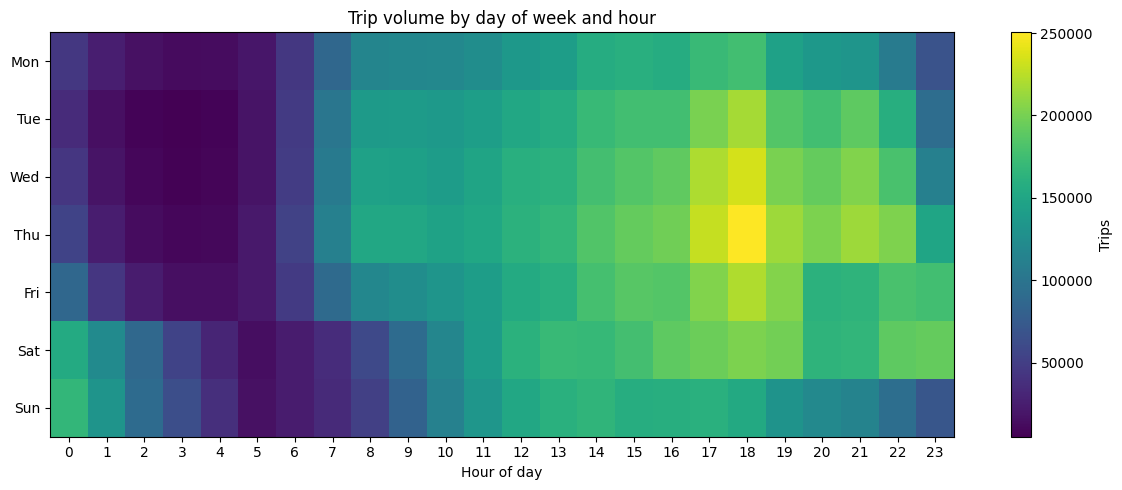

In [ ]:
heat_data = con.sql(f"""
    SELECT
        strftime(tpep_pickup_datetime, '%a') AS dow,
        EXTRACT(hour FROM tpep_pickup_datetime) AS hour,
        COUNT(*) AS trips
    FROM read_parquet([{file_list_sql}])
    GROUP BY dow, hour
""").df()

day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
pivot = heat_data.pivot(index="dow", columns="hour", values="trips").reindex(day_order).fillna(0)

plt.figure(figsize=(12, 5))
plt.imshow(pivot, aspect="auto", cmap="viridis")
plt.colorbar(label="Trips")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.xlabel("Hour of day")
plt.title("Trip volume by day of week and hour")
plt.tight_layout()
plt.show()


**¿La distancia predice el precio del viaje? (distribución de datos muestreada)**

Trazar cada fila supondría renderizar millones de puntos sin ningún beneficio visual —
La cláusula `USING SAMPLE` de DuckDB extrae una muestra aleatoria rápida directamente del motor de agregación,
otro ejemplo de «reducirlo antes de que llegue a pandas».


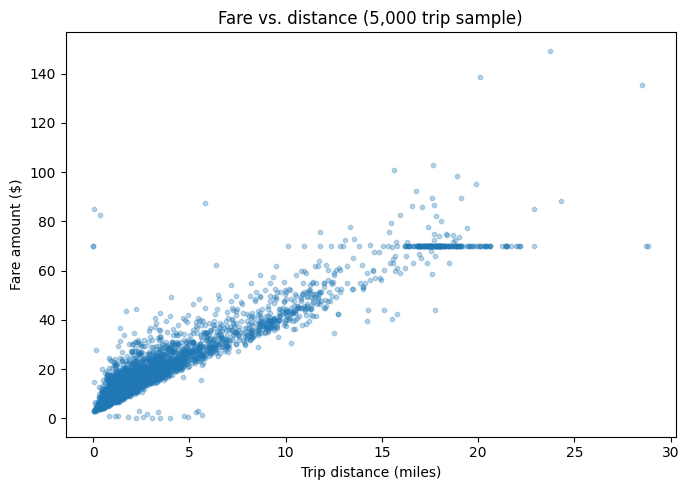

In [ ]:
sample = con.sql(f"""
    SELECT trip_distance, fare_amount
    FROM read_parquet([{file_list_sql}])
    WHERE trip_distance > 0 AND trip_distance < 30
      AND fare_amount > 0 AND fare_amount < 150
    USING SAMPLE 5000
""").df()

plt.figure(figsize=(7, 5))
plt.scatter(sample["trip_distance"], sample["fare_amount"], alpha=0.3, s=10)
plt.xlabel("Trip distance (miles)")
plt.ylabel("Fare amount ($)")
plt.title("Fare vs. distance (5,000 trip sample)")
plt.tight_layout()
plt.show()


**Debate:** ¿Cuál de estas cuatro imágenes influiría realmente en una decisión que alguien
tomara mañana? Esa pregunta sirve de puente hacia el Laboratorio 2.


## 6. Bridge: cuando una máquina no es suficiente

DuckDB acaba de funcionar durante seis meses en una única máquina virtual de Colab sin ningún problema. Pero los verdaderos
sistemas de big data (piensa en todos los viajes de Uber realizados hasta la fecha, todos los pedidos de Amazon) son demasiado grandes para el disk de *cualquier máquina individual*, por no hablar de su RAM. La solución habitual consiste en **dividir los datos
entre varias máquinas y ejecutar el mismo cálculo en cada parte de forma paralela**, para luego combinar
los resultados; esa es la idea que subyace a MapReduce y Spark.

Ejecutemos la misma consulta con PySpark para ver cómo funciona este concepto, al estilo de un motor distribuido.


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder.appName("big-data-demo").getOrCreate()

start = time.time()
sdf = spark.read.parquet(local_files[0])
spark_result = (
    sdf.withColumn("hour", F.hour("tpep_pickup_datetime"))
       .groupBy("hour")
       .agg(F.count("*").alias("trips"), F.avg("fare_amount").alias("avg_fare"))
       .orderBy("hour")
)
spark_result.show(24)
print(f"Spark time: {time.time() - start:.2f} seconds")


+----+------+------------------+
|hour| trips|          avg_fare|
+----+------+------------------+
|   0| 79094|19.202658103016713|
|   1| 53627| 17.52729576519277|
|   2| 37517| 16.48288216008736|
|   3| 24811| 18.15013461770988|
|   4| 16742| 22.51864532313935|
|   5| 18764| 26.61991846088232|
|   6| 41429|21.650398995872234|
|   7| 83719| 18.53918011443055|
|   8|117209| 17.65468274620556|
|   9|128970|17.708415367915187|
|  10|138778| 17.75339376558262|
|  11|150542|17.432059425276748|
|  12|164559|17.476313419503285|
|  13|169903|18.116046450033263|
|  14|182898| 18.94578672265435|
|  15|189359| 18.77463442455851|
|  16|190201|19.121762240997988|
|  17|206257|17.838370576513736|
|  18|212788| 16.72315088256837|
|  19|184032| 17.29479394887858|
|  20|159989|17.695375307052274|
|  21|160888|17.954276204564554|
|  22|143261|18.688929087469532|
|  23|109287|19.757695974818336|
+----+------+------------------+

Spark time: 12.20 seconds


**Comentario:** en esta máquina de Colab en concreto, Spark no es más rápido que DuckDB; tampoco es que se suponga que lo sea.
La ventaja de Spark solo se aprecia una vez que los datos se distribuyen entre *muchas* máquinas.
La sintaxis (`groupBy`, `agg`, `orderBy`) es deliberadamente similar a la de SQL; esa coherencia es la razón por la que estas herramientas resultan familiares una vez que conoces alguna de ellas.


## 7. Práctica n.º 2: convertir una consulta en una acción concreta

Los datos por sí solos no sirven de nada; lo que sirve es tomar una decisión. Utilizando el resultado de tu Pregunta C (o la tabla de consejos por distrito municipal que aparece más arriba), elabora **un gráfico** y **una frase** que el responsable de una empresa de taxis pueda aplicar en la práctica.


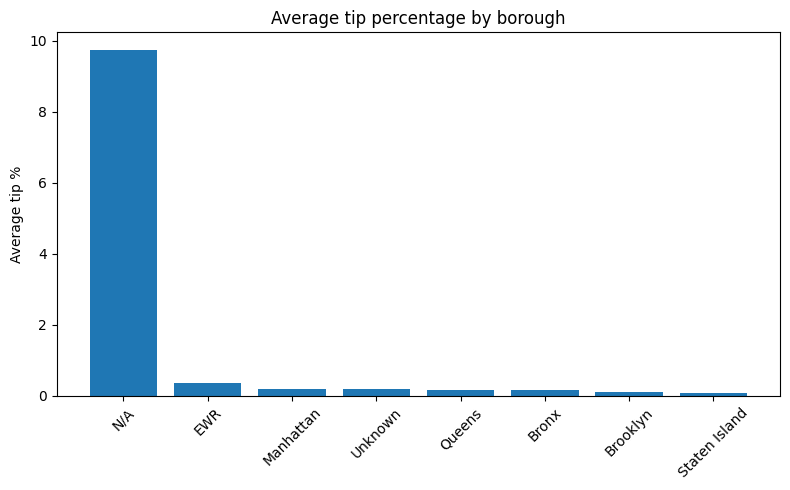

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(tips_by_borough["Borough"], tips_by_borough["avg_tip_pct"])
plt.ylabel("Average tip %")
plt.title("Average tip percentage by borough")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Escribe aquí tu recomendación práctica (haz doble clic para editar esta celda):**

> Ejemplo: «Los conductores que den prioridad a las recogidas en ___ frente a ___ podrían ver un aumento medio de las propinas de ___ puntos porcentuales, según los datos de viajes de los últimos 6 meses».

Sustituye los espacios en blanco por tus propias cifras del gráfico anterior.


## 8. Resumen: dónde encaja esto en un flujo de trabajo real

Todo sistema de big data, por muy grande que sea, sigue más o menos la misma estructura:

**Ingestión** (llegada de datos: sensores, aplicaciones, registros) → **Almacenamiento** (archivos, lagos de datos,
almacenes de datos) → **Procesamiento** (DuckDB, Spark, SQL) → **Presentación** (cuadros de mando, informes,
decisiones como la que acabas de escribir)

Hoy has trabajado directamente con las dos capas centrales:
- **DuckDB**: la herramienta práctica para una sola máquina, ideal para volúmenes de hasta decenas de gigabytes
- **Spark**: la herramienta distribuida para cuando los datos superan por completo la capacidad de una sola máquina

**Conclusión:** la mayoría de los problemas de «big data» del mundo real —incluido casi todo con lo que te encontrarás fuera de la escala de las empresas tecnológicas con billones de filas— se resuelven solo con DuckDB. Spark solo justifica su complejidad cuando una sola máquina es realmente incapaz de albergar los datos.